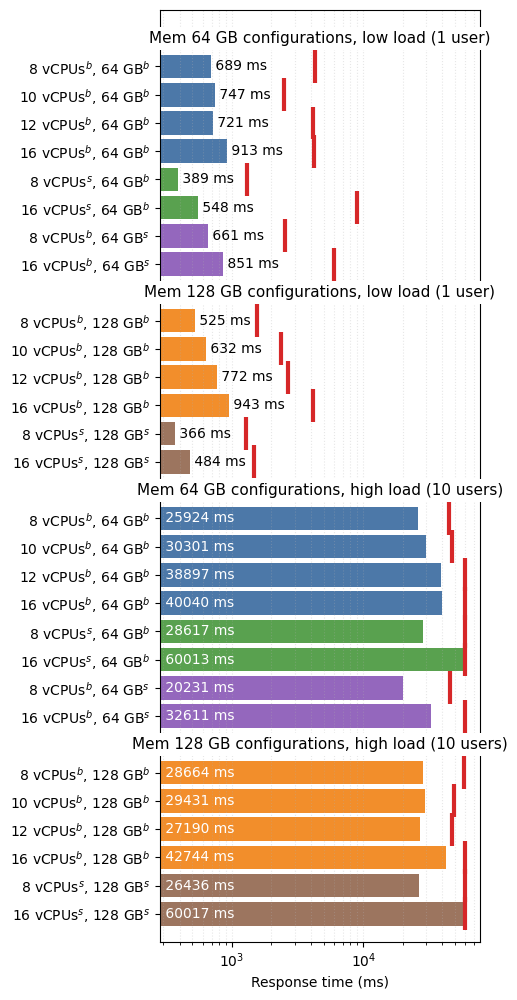

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

# Load data from local CSV file
data_path = Path("analyze_performance_chart.csv")
if not data_path.exists():
    raise FileNotFoundError(f"CSV file not found: {data_path}")
df = pd.read_csv(data_path)

# Order is preserved top-to-bottom as listed.
# Bar entry: (cpu_col, mem_col, cpu_state, mem_state, label, color, metric, tmax_metric, label_at_end)
# Text entry: ("text", label)
order = [
    ("text", "Mem 64 GB configurations, low load (1 user)"),
    ("vCPU_8",  "Mem_64", "b", "b", "8 vCPUs$^b$, 64 GB$^b$",  "#4c78a8", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_10", "Mem_64", "b", "b", "10 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_12", "Mem_64", "b", "b", "12 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_16", "Mem_64", "b", "b", "16 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_8",  "Mem_64", "s", "b", "8 vCPUs$^s$, 64 GB$^b$",  "#59a14f", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_16", "Mem_64", "s", "b", "16 vCPUs$^s$, 64 GB$^b$", "#59a14f", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_8",  "Mem_64", "b", "s", "8 vCPUs$^b$, 64 GB$^s$",  "#9467bd", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_16", "Mem_64", "b", "s", "16 vCPUs$^b$, 64 GB$^s$", "#9467bd", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("text", "Mem 128 GB configurations, low load (1 user)"),
    ("vCPU_8",  "Mem_128", "b", "b", "8 vCPUs$^b$, 128 GB$^b$",  "#f28e2b", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_10", "Mem_128", "b", "b", "10 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_12", "Mem_128", "b", "b", "12 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_16", "Mem_128", "b", "b", "16 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_8",  "Mem_128", "s", "s", "8 vCPUs$^s$, 128 GB$^s$",  "#9c755f", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("vCPU_16", "Mem_128", "s", "s", "16 vCPUs$^s$, 128 GB$^s$", "#9c755f", "Low_E_T_ms", "Low_Tmax_ms", True),
    ("text", "Mem 64 GB configurations, high load (10 users)"),
    ("vCPU_8",  "Mem_64", "b", "b", "8 vCPUs$^b$, 64 GB$^b$",  "#4c78a8", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_10", "Mem_64", "b", "b", "10 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_12", "Mem_64", "b", "b", "12 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_16", "Mem_64", "b", "b", "16 vCPUs$^b$, 64 GB$^b$", "#4c78a8", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_8",  "Mem_64", "s", "b", "8 vCPUs$^s$, 64 GB$^b$",  "#59a14f", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_16", "Mem_64", "s", "b", "16 vCPUs$^s$, 64 GB$^b$", "#59a14f", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_8",  "Mem_64", "b", "s", "8 vCPUs$^b$, 64 GB$^s$",  "#9467bd", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_16", "Mem_64", "b", "s", "16 vCPUs$^b$, 64 GB$^s$", "#9467bd", "High_E_T_ms", "High_Tmax_ms", False),
    ("text", "Mem 128 GB configurations, high load (10 users)"),
    ("vCPU_8",  "Mem_128", "b", "b", "8 vCPUs$^b$, 128 GB$^b$",  "#f28e2b", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_10", "Mem_128", "b", "b", "10 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_12", "Mem_128", "b", "b", "12 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_16", "Mem_128", "b", "b", "16 vCPUs$^b$, 128 GB$^b$", "#f28e2b", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_8",  "Mem_128", "s", "s", "8 vCPUs$^s$, 128 GB$^s$",  "#9c755f", "High_E_T_ms", "High_Tmax_ms", False),
    ("vCPU_16", "Mem_128", "s", "s", "16 vCPUs$^s$, 128 GB$^s$", "#9c755f", "High_E_T_ms", "High_Tmax_ms", False),
]

rows = []
for idx, entry in enumerate(order):
    if entry[0] == "text":
        _, text_label = entry
        rows.append({
            "type": "text",
            "label": text_label,
        })
        continue

    cpu_col, mem_col, cpu_state, mem_state, label, color, metric, tmax_metric, label_at_end = entry
    metric_col = metric
    tmax_col = tmax_metric

    mask = (
        df[cpu_col].fillna("").str.strip().str.lower().eq(cpu_state) &
        df[mem_col].fillna("").str.strip().str.lower().eq(mem_state)
    )
    n = int(mask.sum())
    mean_val = df.loc[mask, metric_col].mean() if n > 0 else None
    mean_tmax = df.loc[mask, tmax_col].mean() if n > 0 else None
    rows.append({
        "type": "bar",
        "label": label,
        "mean": mean_val,
        "tmax": mean_tmax,
        "n": n,
        "color": color,
        "label_at_end": bool(label_at_end),
    })

labels = [r.get("label", "") for r in rows]
epsilon = 1e-3

bar_entries = []
for idx, row in enumerate(rows):
    if row["type"] != "bar":
        continue
    val = row["mean"] if row["mean"] is not None and row["mean"] > 0 else epsilon
    bar_entries.append((idx, val, row["color"], row["mean"], row.get("tmax"), row.get("n", 0), row.get("label_at_end", True)))

bar_height = 0.25  # fixed thickness
spacing = 0.3      # close vertical spacing
y_positions = [i * spacing for i in range(len(labels))]
height = max(5, len(labels) * spacing + 0.5)

fig, ax = plt.subplots(figsize=(5, height))

# Plot bars and collect labels that need to sit at the y-axis
pending_left_labels = []
for y_idx, val, color, mean_val, mean_tmax, n, label_at_end in bar_entries:
    y = y_positions[y_idx]
    bar = ax.barh([y], [val], align="center", color=color, height=bar_height)[0]
    y_center = bar.get_y() + bar.get_height() / 2
    if mean_val is None:
        ax.text(bar.get_width() * 1.05, y_center, "no data", va="center", color="#555", ha="left")
    else:
        if label_at_end:
            ax.text(mean_val, y_center, f" {mean_val:.0f} ms", va="center", ha="left")
        else:
            pending_left_labels.append((y_center, mean_val))
    if mean_tmax is not None:
        ax.plot([mean_tmax, mean_tmax], [y_center - bar_height*0.7, y_center + bar_height*0.7],
                color="#d62728", linewidth=3, solid_capstyle="butt")

# Plot text-only rows centered horizontally with white background
trans = blended_transform_factory(ax.transAxes, ax.transData)
for idx, row in enumerate(rows):
    if row["type"] != "text":
        continue
    y = y_positions[idx]
    ax.text(
        0.5,
        y,
        row["label"],
        ha="center",
        va="center",
        transform=trans,
        fontsize=11,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 1.0, "pad": 3},
    )

# Build ticks and labels; blank out ticks on text rows
tick_positions = []
tick_labels = []
for idx, row in enumerate(rows):
    tick_positions.append(y_positions[idx])
    if row["type"] == "text":
        tick_labels.append("")
    else:
        tick_labels.append(row.get("label", ""))

ax.set_yticks(tick_positions, labels=tick_labels)
# add a bit of headroom above the first row
ax.set_ylim(-spacing, max(y_positions) + spacing)
ax.invert_yaxis()  # preserve the listed order top-to-bottom
ax.set_xlabel("Response time (ms)")
ax.set_xscale("log")
ax.grid(axis="x", which="both", linestyle=":", alpha=0.3)

# Place any left-anchored labels just inside the y-axis after limits are set
x_left = ax.get_xlim()[0]
x_anchor = max(x_left * 1.01, epsilon)
for y_center, mean_val in pending_left_labels:
    ax.text(x_anchor, y_center, f" {mean_val:.0f} ms", va="center", ha="left", color="white")

plt.tight_layout()
output_path = Path("analyze_performance_chart.pdf")
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()
